In [4]:
# first, make sure you have these installed:
# pip install pysrt textblob matplotlib

from datetime import date, datetime, timedelta, time
import srt
from datetime import timedelta, time

# read the file
with open("data2/disney/Aladdin.srt", encoding="utf-8", errors="replace") as f:
    raw = f.read()

subs = list(srt.parse(raw))


In [13]:
# install only what we really need
!pip install transformers[torch] srt matplotlib

# for inline plots in Jupyter
%matplotlib inline


In [14]:
from datetime import date, datetime, timedelta, time
import srt
from transformers import pipeline
import matplotlib.pyplot as plt

# plotting defaults
plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (14, 5)

# build a Transformers “sentiment-analysis” pipeline
# maps each chunk to {'label': 'POSITIVE'|'NEGATIVE', 'score': float}
sent = pipeline('sentiment-analysis')

def create_intervals(start: time, end: time, delta: timedelta):
    """Return list of time‐points from start up through end stepping delta."""
    points = []
    current = datetime.combine(date.today(), start)
    stop    = datetime.combine(date.today(), end)
    while current <= stop:
        points.append(current.time())
        current += delta
    return points

def average(xs):
    return sum(xs)/len(xs) if xs else 0.0

def get_sentiment(srt_path: str, interval_minutes: int=2):
    # 1) read & parse
    raw = open(srt_path, encoding='utf-8', errors='replace').read()
    subs = list(srt.parse(raw))

    # 2) bucket endpoints
    start_time = time(0,0,0)
    last_end   = (datetime.combine(date.today(), time(0,0,0))
                  + subs[-1].end).time()
    delta      = timedelta(minutes=interval_minutes)
    buckets    = create_intervals(start_time, last_end, delta)

    # 3) sweep through subtitles, accumulating text up to each bucket
    scores, idx = [], 0
    for cutoff in buckets:
        texts = []
        while idx < len(subs) and (datetime.combine(date.today(), time(0,0,0))
                                    + subs[idx].end).time() < cutoff:
            texts.append(subs[idx].content)
            idx += 1
        chunk = " ".join(texts) or " "
        r = sent(chunk[:512])  # limit length for speed
        label, score = r[0]['label'], r[0]['score']
        # map POSITIVE→+score, NEGATIVE→−score
        polarity = score if label=='POSITIVE' else -score
        scores.append(polarity)

    # prepend t=0
    return [start_time]+buckets, [0.0]+scores


/home/codespace/.python/current/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


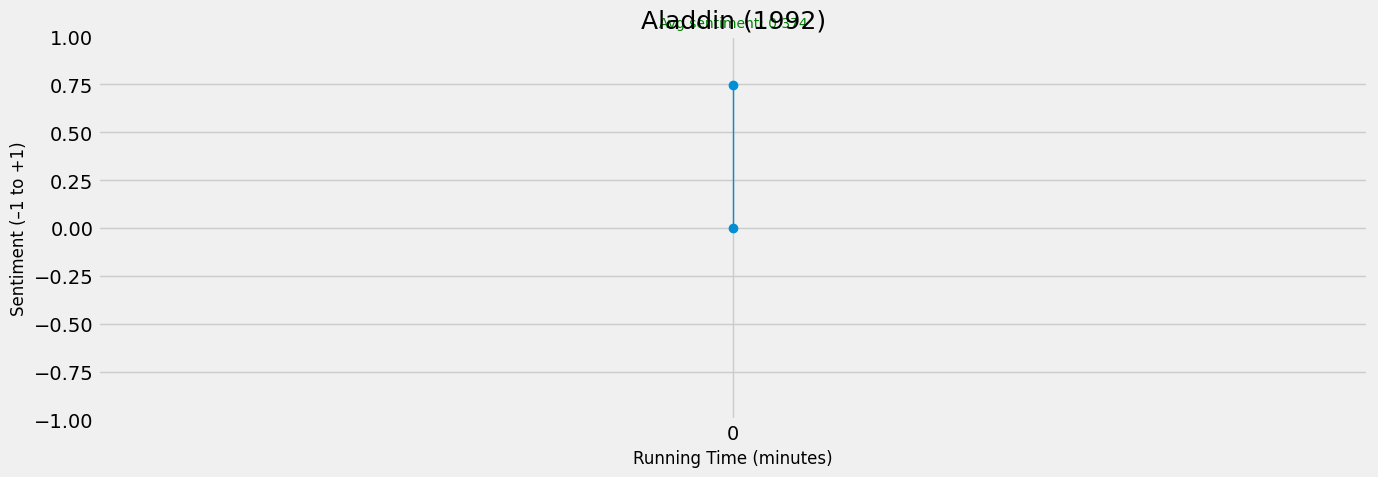

FileNotFoundError: [Errno 2] No such file or directory: 'data2/disney/The_Little_Mermaid.srt'

In [16]:
import numpy as np

# list your files + titles here
movies = [
    ("data2/disney/Aladdin.srt", "Aladdin (1992)"),
    ("data2/disney/The_Little_Mermaid.srt", "The Little Mermaid (1989)"),
    ("data2/disney/Tangled.srt", "Tangled (2010)"),
    ("data2/disney/Mulan.srt", "Mulan (1998)"),
    ("data2/disney/Beauty_and_the_Beast.srt", "Beauty and the Beast (1991)"),
    ("data2/disney/Cinderella.srt", "Cinderella (1950)"),
    ("data2/disney/Snow_White_and_the_Seven_Dwarfs.srt", "Snow White and the Seven Dwarfs (1937)"),
]

for path, title in movies:
    times, scores = get_sentiment(path, interval_minutes=2)

    # convert datetime.time → “minutes since start”
    xs = [(t.hour * 3600 + t.minute * 60 + t.second) / 60 for t in times]

    plt.figure()
    plt.plot(xs, scores, marker='o', linewidth=1)
    plt.title(title, fontsize=18)
    plt.ylim(-1, 1)
    plt.xlabel("Running Time (minutes)", fontsize=12)
    plt.ylabel("Sentiment (–1 to +1)", fontsize=12)

    # annotate average
    avg = average(scores)
    mid_x = xs[len(xs)//2]
    plt.text(mid_x, 1.05, f"Avg sentiment: {avg:.3f}", 
             ha='center', color='green', fontsize=10)

    # nice x-ticks every 30 minutes (adjust to taste)
    max_min = xs[-1]
    ticks = np.arange(0, max_min + 1, 30)
    plt.xticks(ticks)

    plt.grid(True)
    plt.tight_layout()

    # show (or save)
    plt.show()
    # plt.savefig(f"{title.replace(' ', '_')}.png", dpi=150)


In [17]:
# Cell 1: install
!pip install srt textblob matplotlib numpy


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [1]:
# Cell 2: imports
import srt, numpy as np
from textblob import TextBlob
import matplotlib.pyplot as plt


In [2]:
# Cell 3: compute sentiment over time using srt
def get_sentiment(srt_path, interval_min=2):
    # 1) parse file
    with open(srt_path, encoding="utf-8", errors="replace") as f:
        subs = list(srt.parse(f.read()))
    # 2) convert end-times to seconds
    ends = [s.end.total_seconds() for s in subs]
    max_sec = max(ends) if ends else 0
    delta_sec = interval_min * 60
    # 3) make buckets at 0, delta, 2*delta, … 
    buckets = np.arange(0, max_sec + delta_sec, delta_sec)
    sentiments = []
    idx = 0
    # 4) for each bucket, grab all subs ending ≤ that time
    for b in buckets:
        texts = []
        while idx < len(subs) and subs[idx].end.total_seconds() <= b:
            texts.append(subs[idx].content)
            idx += 1
        joined = " ".join(texts)
        sentiments.append(TextBlob(joined).sentiment.polarity)
    # 5) convert buckets → minutes
    xs = buckets / 60.0
    return xs, sentiments


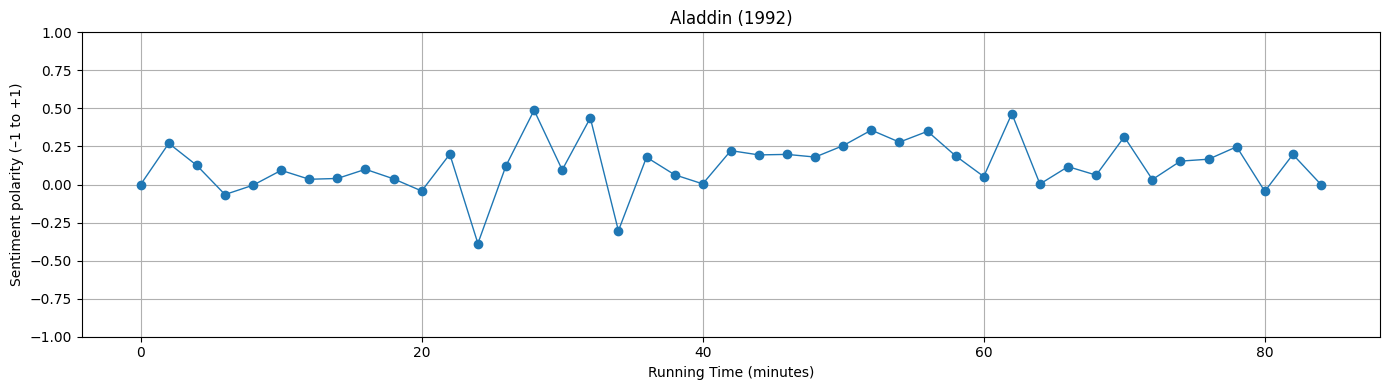

In [3]:
# Cell 4: plot it
path = "data2/disney/Aladdin.srt"
xs, ys = get_sentiment(path, interval_min=2)

plt.figure(figsize=(14,4))
plt.plot(xs, ys, marker="o", linewidth=1)
plt.title("Aladdin (1992)")
plt.xlabel("Running Time (minutes)")
plt.ylabel("Sentiment polarity (–1 to +1)")
plt.ylim(-1, 1)
plt.grid(True)
plt.tight_layout()
plt.show()


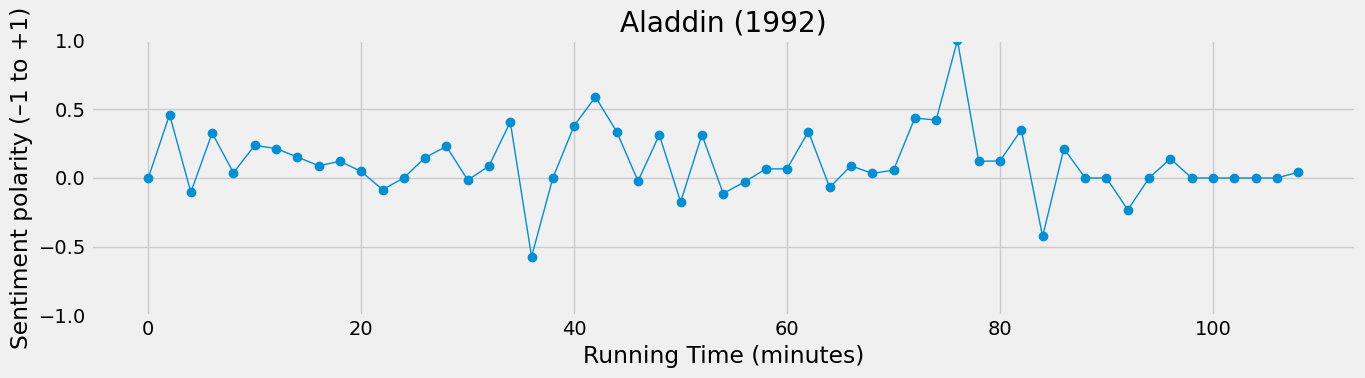

In [21]:
# Cell 4: plot it
path = "data2/disney/Moana.srt"
xs, ys = get_sentiment(path, interval_min=2)

plt.figure(figsize=(14,4))
plt.plot(xs, ys, marker="o", linewidth=1)
plt.title("Aladdin (1992)")
plt.xlabel("Running Time (minutes)")
plt.ylabel("Sentiment polarity (–1 to +1)")
plt.ylim(-1, 1)
plt.grid(True)
plt.tight_layout()
plt.show()


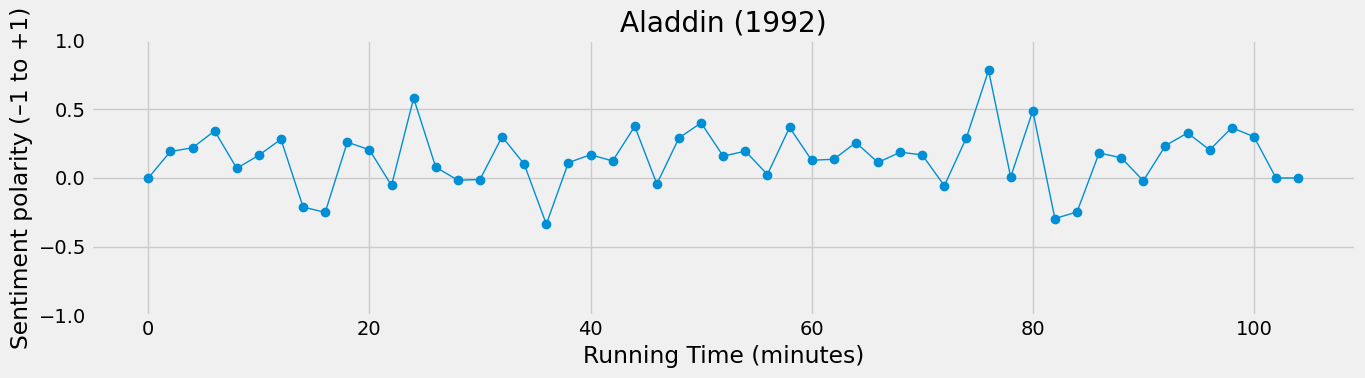

In [28]:
# Cell 4: plot it
path = "data2/ghibli/When.Marnie.Was.There.srt"
xs, ys = get_sentiment(path, interval_min=2)

plt.figure(figsize=(14,4))
plt.plot(xs, ys, marker="o", linewidth=1)
plt.title("Aladdin (1992)")
plt.xlabel("Running Time (minutes)")
plt.ylabel("Sentiment polarity (–1 to +1)")
plt.ylim(-1, 1)
plt.grid(True)
plt.tight_layout()
plt.show()
